导入依赖（机器人启动前在要启动ROS文件，复制到终端运行）

roslaunch akai_fr_hardware fr3_with_jodell_epg_moveit_real_python.launch 

初始化库

In [1]:
import numpy as np
from akai_fr import AkaiFr
from akai_gemini335 import AkaiGemini335
from akai_gemini335_ros import AkaiGemini335ROS
from matplotlib import pyplot as plt
import os
import time
import rospy
import ultralytics
from akai_yolo import AkaiYoloSegment
from akai_fr_ros import AkaiFRMoveIt
from ultralytics import YOLO
import cv2
from akai import tf3d
from akai_ros import akai_pose
from akai_ros import akai_kinematic
import akai_ros
from akai_ros import akai_rviz
from akai_ros import akai_joint
from akai_ros import akai_moveit
from akai import M, MM, RAD, DEG
import math
from akai_jodell_epg import AkaiJodellEPGGripper
import yaml
with open("calibration_matrix.yaml") as f:
    data = yaml.safe_load(f)
camera_matrix = np.array(data['camera_matrix'])
dist_coeff = np.array(data['dist_coeff'])
import warnings
warnings.filterwarnings("ignore",category=RuntimeWarning)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


INFO - 2025-07-19 18:09:51,821 - topics - topicmanager initialized


[INFO][pyorbbecsdk]添加动态链接库检索路径
/usr/local/lib/python3.8/dist-packages/akai_gemini335/lib/pyorbbecsdk/linux
load extensions from /usr/local/lib/python3.8/dist-packages/akai_gemini335/lib/pyorbbecsdk/linux/extensions


初始化9点标定法的预测函数（直接调用即可）

In [2]:
from scipy.optimize import linear_sum_assignment
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

class ZCoordinatePredictor:
    def __init__(self, degree=2):
        """
        初始化Z坐标预测器
        :param degree: 多项式回归的阶数（默认2阶）
        """
        self.degree = degree
        self.poly = PolynomialFeatures(degree=degree)
        self.model = LinearRegression()
    
    def fit(self, pixel_coords, z_coords):
        """
        训练预测模型
        :param pixel_coords: 9个像素坐标的数组，形状为(9, 2)
        :param z_coords: 对应的9个Z坐标值，形状为(9,)
        """
        # 生成多项式特征
        X_poly = self.poly.fit_transform(pixel_coords)
        # 训练线性回归模型
        self.model.fit(X_poly, z_coords)
    
    def predict(self, pixel_coord):
        """
        预测目标点的Z坐标
        :param pixel_coord: 目标点的像素坐标，形状为(2,)
        :return: 预测的Z坐标
        """
        # 转换为多项式特征
        point_poly = self.poly.transform([pixel_coord])
        # 预测Z坐标
        return self.model.predict(point_poly)[0]
pixel_coords = np.array([
    [157 , 64],   [579 , 77],   [1044 , 46],
    [178 , 403],   [628 , 393],   [1072 , 360],
    [154 , 607],   [650 , 536],    [1098 , 625]
])
z_coords = np.array([152.201,151.501,152.501,150.901,149.701,150.853,151.053,149.053,149.853])

# 2. 创建并训练预测模型
predictor = ZCoordinatePredictor(degree=2)
predictor.fit(pixel_coords, z_coords)

初始化随机俄罗斯方块的摆放策划（用于进阶任务）

In [3]:
from ctypes import *    #pip ctypes库，并导入库
test = CDLL("/home/zhangyu/桌面/代码/libtetris.so")    #调用当前目录下叫test的dll文件，dll文件是C生成的动态链接库
cube_count=[2,3,0,2,3,4,1]#LR LL ZL ZR O T Line
test.DFS.restype = c_char_p
def get_put_table(cube_count):
    result = test.DFS(cube_count[0], cube_count[1], cube_count[2], cube_count[3], cube_count[4], cube_count[5],
                      cube_count[6])  # 调用库里的函数sum，求和函数
    result = result.decode('gbk')
    cube_list0 = result.split(',')
    length = len(cube_list0) // 4
    cube_list = []
    for i in range(length):
        cube_list.append([])
        cube_list[i].append(float(cube_list0[i * 4 + 2])+0.5)
        cube_list[i].append(float(cube_list0[i * 4 + 3])+0.5)
        cube_list[i].append(float(cube_list0[i * 4 + 1]))
        cube_name=cube_list0[i * 4]
        if(cube_list0[i * 4]=="Line"):
            cube_name='line'
        cube_list[i].append(cube_name)
    # print(cube_list, cube_list0[-1])  # 打印结果
    cube_sum = 0
    for i in cube_count:
        cube_sum = cube_sum + i * 4
    level = cube_sum // 10
    print("极限填满行", level)
    return cube_list,cube_list0[-1]
print(get_put_table(cube_count))

极限填满行 6
([[9.0, 2.0, 180.0, 'LR'], [8.0, 1.0, 0.0, 'LR'], [6.0, 2.0, -90.0, 'LL'], [4.0, 1.0, 0.0, 'LL'], [2.0, 1.5, 0.0, 'ZR'], [3.5, 3.0, -90.0, 'T'], [1.5, 3.0, 90.0, 'T'], [9.5, 3.5, 0.0, 'O'], [8.0, 4.5, 90.0, 'line'], [6.5, 4.0, -90.0, 'T'], [4.5, 5.0, 90.0, 'ZR'], [2.5, 4.5, 0.0, 'O'], [9.5, 5.5, 0.0, 'O'], [6.0, 5.5, 180.0, 'T'], [2.0, 6.0, 180.0, 'LL']], '6')


初始化一部分函数（只有get_put_pose需要调参数，其它不用管）

In [4]:
def detect_L_block_rotation(mask, box):
    """
    识别L型俄罗斯方块的旋转角度（顺时针方向）
    
    参数:
        mask (numpy.ndarray): 二值化掩码图像，方块内部为255，背景为0
        box (tuple): 最小外接矩形，格式为(center, (width, height), angle)
                    其中center是(x, y)，angle是旋转角度（度）
    
    返回:
        float: 旋转角度（度），顺时针为正，范围[-180, 180]
              0度: L开口朝右（长边垂直向下）
    """
    # 解包矩形信息
    center, (width, height), angle = box
    
    # 确定长边和短边
    long_edge = max(width, height)
    short_edge = min(width, height)
    
    # 计算小方块尺寸
    square_size = long_edge / 3.0
    
    # 获取旋转矩阵（将矩形旋转到水平）
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    # 添加平移以保证图像完整
    cos = np.abs(M[0, 0])
    sin = np.abs(M[0, 1])
    new_width = int((height * sin) + (width * cos))
    new_height = int((height * cos) + (width * sin))
    M[0, 2] += (new_width / 2) - center[0]
    M[1, 2] += (new_height / 2) - center[1]
    
    # 旋转图像
    rotated_mask = cv2.warpAffine(mask, M, (new_width, new_height), flags=cv2.INTER_NEAREST)
    
    # 计算旋转后的矩形区域
    rect_center = (new_width // 2, new_height // 2)
    rect_x = int(rect_center[0] - short_edge / 2)
    rect_y = int(rect_center[1] - long_edge / 2)
    rect_w = int(short_edge)
    rect_h = int(long_edge)
    
    # 提取矩形区域
    rect_region = rotated_mask[rect_y:rect_y+rect_h, rect_x:rect_x+rect_w]
    
    # 分割为3列2行（2×3网格）
    grid = np.zeros((2, 3), dtype=float)
    cell_height = rect_h // 2
    cell_width = rect_w // 3
    
    # 计算每个小方块的平均像素值
    for i in range(2):
        for j in range(3):
            y_start = i * cell_height
            y_end = (i+1) * cell_height
            x_start = j * cell_width
            x_end = (j+1) * cell_width
            
            cell = rect_region[y_start:y_end, x_start:x_end]
            grid[i, j] = np.mean(cell) if cell.size > 0 else 0
    
    # 二值化网格（阈值127）
    binary_grid = grid > 127
    
    # 寻找有方块的位置
    positions = []
    for i in range(2):
        for j in range(3):
            if binary_grid[i, j]:
                positions.append((j, i))  # (x, y)
    
    # 确保有4个小方块（L型由4个方块组成）
    if len(positions) != 4:
        # 如果找不到4个方块，尝试调整阈值
        binary_grid = grid > 50
        positions = []
        for i in range(2):
            for j in range(3):
                if binary_grid[i, j]:
                    positions.append((j, i))
        if len(positions) != 4:
            return 0.0  # 默认角度
    
    # 计算重心
    center_x = sum(p[0] for p in positions) / 4.0
    center_y = sum(p[1] for p in positions) / 4.0
    
    # 计算每个点相对于重心的向量
    vectors = [(p[0] - center_x, p[1] - center_y) for p in positions]
    
    # 找到最长的边（3个共线点）
    max_length = 0
    long_edge_points = None
    for i in range(4):
        for j in range(i+1, 4):
            for k in range(j+1, 4):
                # 计算三点形成的向量
                v1 = (positions[j][0] - positions[i][0], positions[j][1] - positions[i][1])
                v2 = (positions[k][0] - positions[i][0], positions[k][1] - positions[i][1])
                
                # 计算向量长度
                length = np.sqrt(v1[0]**2 + v1[1]**2) + np.sqrt(v2[0]**2 + v2[1]**2)
                
                if length > max_length:
                    max_length = length
                    long_edge_points = [positions[i], positions[j], positions[k]]
    
    # 找到短边点（第四个点）
    short_edge_point = [p for p in positions if p not in long_edge_points][0]
    
    # 计算长边的方向向量
    long_edge_center_x = sum(p[0] for p in long_edge_points) / 3.0
    long_edge_center_y = sum(p[1] for p in long_edge_points) / 3.0
    
    # 计算从长边中心指向短边点的向量
    vector_x = short_edge_point[0] - long_edge_center_x
    vector_y = short_edge_point[1] - long_edge_center_y
    
    # 计算角度（弧度）
    angle_rad = np.arctan2(vector_y, vector_x)
    # 转换为度
    angle_deg = np.degrees(angle_rad)
    
    # 调整角度到[-180, 180]范围
    angle_deg = (angle_deg + 180) % 360 - 180
    
    return angle_deg

def calculate_displacement(theta_deg, L):
    """
    计算A点绕其正下方O点旋转后的位移
    参数:
        theta_deg: 旋转角度(顺时针0-180°,逆时针-180°~0°)
        L: OA的距离
    返回:
        (dx, dy): B点相对于A点的位移
    """
    # 默认A点在坐标系原点(0,0)，O点在A点正下方(0,-L)
    A = (0, 0)
    O = (0, -L)
    
    # 将角度转换为弧度（数学坐标系，顺时针为负）
    theta_rad = math.radians(-theta_deg)
    
    # 计算旋转后的B点坐标
    cos_theta = math.cos(theta_rad)
    sin_theta = math.sin(theta_rad)
    
    # 旋转后的相对坐标（相对于O点）
    b_x_rel = L * sin_theta  # 因为初始A在O的正上方
    b_y_rel = L * cos_theta
    
    # 转换回绝对坐标
    Bx = O[0] + b_x_rel
    By = O[1] + b_y_rel
    
    # 计算位移（B - A）
    dx = Bx - A[0]
    dy = By - A[1]
    
    return (dx, dy)
def get_precise_angle(rect,box,category,img):
    height,width=img.shape[:2]
    if(category=="line"):
        l=math.sqrt((box[0][0]-box[3][0])*(box[0][0]-box[3][0])+(box[0][1]-box[3][1])*(box[0][1]-box[3][1]))
        theta=rect[2]
        if(l/max(rect[1][0],rect[1][1])>0.9 and l/max(rect[1][0],rect[1][1])<1.1):
            theta=rect[2]+90
    elif(category=="O"):
        l=math.sqrt((box[0][0]-box[3][0])*(box[0][0]-box[3][0])+(box[0][1]-box[3][1])*(box[0][1]-box[3][1]))
        theta=rect[2]
        if(l/max(rect[1][0],rect[1][1])>0.9 and l/max(rect[1][0],rect[1][1])<1.1):
            theta=rect[2]+90
        theta=theta%90
    elif(category=="ZL" or category=="ZR"):
        theta=rect[2]
        l=math.sqrt((box[0][0]-box[3][0])*(box[0][0]-box[3][0])+(box[0][1]-box[3][1])*(box[0][1]-box[3][1]))
        if(l/min(rect[1][0],rect[1][1])>0.9 and l/min(rect[1][0],rect[1][1])<1.1):
            theta=rect[2]+90
    elif(category=="T"):
        theta=rect[2]
        l=math.sqrt((box[0][0]-box[3][0])*(box[0][0]-box[3][0])+(box[0][1]-box[3][1])*(box[0][1]-box[3][1]))
        if(l/min(rect[1][0],rect[1][1])>0.9 and l/min(rect[1][0],rect[1][1])<1.1):
            x=(int)(rect[0][0]/2.0+box[1][0]/2.0)
            y=(int)(rect[0][1]/2.0+box[1][1]/2.0)
            x1=(int)(rect[0][0]/2.0+box[3][0]/2.0)
            y1=(int)(rect[0][1]/2.0+box[3][1]/2.0)
            if(x<0):
                x=0
            if(x>=width):
                x=width-1
            if(y<0):
                y=0
            if(y>=height):
                y=height-1
            if(x1<0):
                x1=0
            if(x1>=width):
                x1=width-1
            if(y1<0):
                y1=0
            if(y1>=height):
                y1=height-1
            if(img[y][x]==0):
                theta=theta+270
            elif(img[y1][x1]==0):
                theta=theta+90
        elif(l/max(rect[1][0],rect[1][1])>0.9 and l/max(rect[1][0],rect[1][1])<1.1):
            x=(int)(rect[0][0]/2.0+box[0][0]/2.0)
            y=(int)(rect[0][1]/2.0+box[0][1]/2.0)
            if(x<0):
                x=0
            if(x>=width):
                x=width-1
            if(y<0):
                y=0
            if(y>=height):
                y=height-1
            if(img[y][x]==0):
                theta=theta+180
    elif(category=="LL"):
        theta=rect[2]
        l=math.sqrt((box[0][0]-box[3][0])*(box[0][0]-box[3][0])+(box[0][1]-box[3][1])*(box[0][1]-box[3][1]))
        if(l/max(rect[1][0],rect[1][1])>0.9 and l/max(rect[1][0],rect[1][1])<1.1):#如果下边是长边
            x=(int)(rect[0][0]/2.0+box[3][0]/2.0)
            y=(int)(rect[0][1]/2.0+box[3][1]/2.0)
            if(x<0):
                x=0
            if(x>=width):
                x=width-1
            if(y<0):
                y=0
            if(y>=height):
                y=height-1
            if((int)(img[y][x]+img[y][x-1]+img[y][x+1]+img[y-1][x]+img[y-1][x+1]+img[y-1][x-1]+img[y+1][x]+img[y+1][x-1]+img[y+1][x+1])==0):
                theta=theta+180
        if(l/min(rect[1][0],rect[1][1])>0.9 and l/min(rect[1][0],rect[1][1])<1.1):#如果下边是短边
            x=(int)(rect[0][0]/2.0+box[0][0]/2.0)
            y=(int)(rect[0][1]/2.0+box[0][1]/2.0)
            if(x<0):
                x=0
            if(x>=width):
                x=width-1
            if(y<0):
                y=0
            if(y>=height):
                y=height-1
            if((int)(img[y][x]+img[y][x-1]+img[y][x+1]+img[y-1][x]+img[y-1][x+1]+img[y-1][x-1]+img[y+1][x]+img[y+1][x-1]+img[y+1][x+1])==0):
                theta=theta+270
            else:
                theta=theta+90
        if(box[0][1]==box[3][1]):
            x=(int)(rect[0][0]/2.0+box[1][0]/2.0)
            y=(int)(rect[0][1]/2.0+box[1][1]/2.0)
            if(x<0):
                x=0
            if(x>=width):
                x=width-1
            if(y<0):
                y=0
            if(y>=height):
                y=height-1
            if((int)(img[y][x]+img[y][x-1]+img[y][x+1]+img[y-1][x]+img[y-1][x+1]+img[y-1][x-1]+img[y+1][x]+img[y+1][x-1]+img[y+1][x+1])==0):
                theta=0
            else:
                theta=180
    elif(category=="LR"):
        theta=rect[2]
        l=math.sqrt((box[0][0]-box[3][0])*(box[0][0]-box[3][0])+(box[0][1]-box[3][1])*(box[0][1]-box[3][1]))
        if(l/max(rect[1][0],rect[1][1])>0.9 and l/max(rect[1][0],rect[1][1])<1.1):
            x=(int)(rect[0][0]/2.0+box[0][0]/2.0)
            y=(int)(rect[0][1]/2.0+box[0][1]/2.0)
            if(x<0):
                x=0
            if(x>=width):
                x=width-1
            if(y<0):
                y=0
            if(y>=height):
                y=height-1
            if(img[y][x]==0):
                theta=theta+180
        elif(l/min(rect[1][0],rect[1][1])>0.9 and l/min(rect[1][0],rect[1][1])<1.1):
            x=(int)(rect[0][0]/2.0+box[1][0]/2.0)
            y=(int)(rect[0][1]/2.0+box[1][1]/2.0)
            if(x<0):
                x=0
            if(x>=width):
                x=width-1
            if(y<0):
                y=0
            if(y>=height):
                y=height-1
            if(img[y][x]==0):
                theta=theta+270
            else:
                theta=theta+90
        elif(img[y][x]==0):
            theta=theta+180
            if(l/min(rect[1][0],rect[1][1])>0.9 and l/min(rect[1][0],rect[1][1])<1.1):
              theta=rect[2]+90
        if(box[0][1]==box[3][1]):
            x=(int)(rect[0][0]/2.0+box[2][0]/2.0)
            y=(int)(rect[0][1]/2.0+box[2][1]/2.0)
            if(x<0):
                x=0
            if(x>=width):
                x=width-1
            if(y<0):
                y=0
            if(y>=height):
                y=height-1
            if(img[y][x]==0):
                theta=0
            else:
                theta=180
    elif(category=="board"):
        l=math.sqrt((box[0][0]-box[3][0])*(box[0][0]-box[3][0])+(box[0][1]-box[3][1])*(box[0][1]-box[3][1]))
        theta=rect[2]
        if(l/max(rect[1][0],rect[1][1])>0.9 and l/max(rect[1][0],rect[1][1])<1.1):
            theta=rect[2]-90
        # theta=theta%90
    else:
        theta=rect[2]
        l=math.sqrt((box[0][0]-box[3][0])*(box[0][0]-box[3][0])+(box[0][1]-box[3][1])*(box[0][1]-box[3][1]))
        if(l/min(rect[1][0],rect[1][1])>0.9 and l/min(rect[1][0],rect[1][1])<1.1):
            theta=rect[2]+90
    return theta

def  normalize_angle(t1,t2):
    if(t1<0):
        t1=t1+360
    if(t1>360):
        t1=t1-360
    if(t2<0):
        t2=t2+360
    if(t2>360):
        t2=t2-360
    return t1,t2
def calculate_rotated_offset(dx, dy, theta_degrees):
    
    dx=(dx-5.5)*20
    dy=(dy-7.5)*20
    theta_rad = math.radians(theta_degrees)
    cos_theta = math.cos(theta_rad)
    sin_theta = math.sin(theta_rad)
    
    # 顺时针旋转公式（θ 为正）
    x_offset = dx * cos_theta + dy * sin_theta
    y_offset = -dx * sin_theta + dy * cos_theta
    
    return (x_offset, y_offset)
def get_put_pose(x,y,board_list):
    global all_depth
    # global shooting_angle
    shooting_angle=[-280.575,25.665,382.61,-180,0,90]#拍摄姿态

    X,Y=calculate_rotated_offset(x,y,board_list[2])
    set_angle=shooting_angle
    base_x=board_list[0]-Y-2-0.5+2+1+0.3-4+3+3+5-2.5-2.5-1-1.5-0.5+1#修改X偏移量
    base_y=board_list[1]+X-1+1-1.2+0.6+10-5+1.25-2.5-2.5-2.5+0.8+0.5#修改Y偏移量
    base_z=shooting_angle[2] - all_depth + 100 -66 +20#没用不用管
    test_point=(x,y)
    transformed_point = calibrator.transform(test_point)
    set_angle[0]=    transformed_point[0]
    set_angle[1]=transformed_point[1]
    set_angle[2]=base_z
    return set_angle
# def get_location(x,y,deep):#0.57373623
#     return (x-640)*0.71809906205,(y-360)*0.71809906205
# def get_position_angle(position):
#     global arm1
#     tool_postion=[0,0,0]
#     ref_rpy_deg=[0,0,0]  
#     tool_postion[0]=position[0]
#     tool_postion[1]=position[1]
#     tool_postion[2]=position[2]
#     ref_rpy_deg[0]=position[3]
#     ref_rpy_deg[1]=position[4]
#     ref_rpy_deg[2]=position[5]
#     print(tool_postion,ref_rpy_deg)
#     ret, pose_base_link2tool, joint_angle_deg = arm1.search_pose_by_posi(tool_postion, ref_rpy_deg=ref_rpy_deg)
#     print("是否成功",ret)
#     return joint_angle_deg[0],joint_angle_deg[5]

测试（不用管，用来调试get_put_pose函数中x和y的偏移量，后期修改成标定法）

In [198]:
put_pose=get_put_pose(1,1,board_list)
put_pose[2]=151
put_pose[5]=shooting_angle[5]
arm.set_tool_pose(put_pose)#到托盘那里
print(put_pose)

[-225.15999, -71.033, 151, -180, 0, 90]


启动ROS节点（必须运行）

In [5]:
rospy.init_node('test_akai_fr_moveit',
                anonymous=False)

初始化相机

In [6]:
camera = AkaiGemini335(yaml_path="color_block（复件）（复件）.yaml") 
arm = AkaiFRMoveIt()
T_world2camera_m = arm.akai_move_group.get_link_relative_transform("world", "camera_link")
T_world2base_link_m = arm.akai_move_group.get_link_relative_transform("world", "base_link")
camera_ros = AkaiGemini335ROS(camera, T_world2camera_m, \
                                  enable_pub_camera_mesh=False)
T_base_link2camera_m = arm.akai_move_group.get_link_relative_transform("base_link", "camera_link")

[INFO] 相机初始化过程中，前几帧可能会捕获异常的警告(WARN)，是正常现象。
[INFO] 相机初始化完成，缓冲区已清理
[INFO] 当前机型为: unset
机械臂关节角度约束: (单位°)
* 关节 #1, 下限: -175, 上限：175, 默认值: 0
* 关节 #2, 下限: -160, 上限：0, 默认值: -114
* 关节 #3, 下限: 0, 上限：150, 默认值: 87
* 关节 #4, 下限: -265, 上限：85, 默认值: -66
* 关节 #5, 下限: -175, 上限：175, 默认值: -90
* 关节 #6, 下限: -175, 上限：175, 默认值: 0
[INFO] 机械臂型号: fr20
[INFO] 载入连杆尺寸与关节零点偏移量
* d1 = 215.703
* a2 = 1000.28
* a3 = 717.338
* d4 = 167.405
* d5 = 138.426
* d6 = 119.654
注: 实际akai fr的运动学求解器中, d5用的是负值
[INFO] 是否使用真机: False


[ WARN] [1752919816.572681278]: IK plugin for group 'arm_body' relies on deprecated API. Please implement initialize(RobotModel, ...).


[ INFO] [1752919816.515845277]: Loading robot model 'fr3v6'...
[ INFO] [1752919816.516211199]: No root/virtual joint specified in SRDF. Assuming fixed joint
[ INFO] [1752919816.574369238]: IK Using joint link1 -3.05433 3.05433
[ INFO] [1752919816.574386108]: IK Using joint link2 -2.79253 0
[ INFO] [1752919816.574391963]: IK Using joint link3 0 2.61799
[ INFO] [1752919816.574397223]: IK Using joint link4 -4.62512 1.48353
[ INFO] [1752919816.574403712]: IK Using joint link5 -3.05433 3.05433
[ INFO] [1752919816.574410870]: IK Using joint link6 -3.05433 3.05433
[ INFO] [1752919816.574423606]: Looking in common namespaces for param name: arm_body/position_only_ik
[ INFO] [1752919816.574891497]: Looking in common namespaces for param name: arm_body/solve_type
[ INFO] [1752919816.575542383]: Using solve type Speed
[ INFO] [1752919817.727025131]: Ready to take commands for planning group arm_body.
[INFO] 指定姿态设定的目标参考坐标系: base_link


[ WARN] [1752919819.738886872]: Joint values for monitored state are requested but the full state is not known


查询到腕关节到相机坐标系的变换: 
[[  1.      0.023   0.002 -13.17 ]
 [ -0.023   1.     -0.003 -89.86 ]
 [ -0.002   0.003   1.     95.81 ]
 [  0.      0.      0.      1.   ]]


加载yolo模型

In [7]:
model_path="/home/zhangyu/桌面/best5.14.pt"
print("[INFO] 开始YoloV8模型加载")
model=YOLO(model_path)

[INFO] 开始YoloV8模型加载


托盘4点标定

In [8]:
import numpy as np

class ArmCalibrator:
    def __init__(self):
        self.H = None  # 变换矩阵
        
    def calibrate(self, src_points, dst_points):
        """
        通过4个对应点计算变换矩阵
        :param src_points: 机械臂坐标系中的4个点 [左上, 左下, 右上, 右下]
        :param dst_points: 实际坐标系中的对应4个点 [左上, 左下, 右上, 右下]
        """
        if len(src_points) != 4 or len(dst_points) != 4:
            raise ValueError("需要提供4个源点和4个目标点")
            
        src = np.array(src_points, dtype=np.float32)
        dst = np.array(dst_points, dtype=np.float32)
        
        # 构建线性方程组 A * h = b
        A = []
        b = []
        for i in range(4):
            x, y = src[i]
            u, v = dst[i]
            A.append([x, y, 1, 0, 0, 0, -u*x, -u*y])
            A.append([0, 0, 0, x, y, 1, -v*x, -v*y])
            b.extend([u, v])
        
        A = np.array(A, dtype=np.float32)
        b = np.array(b, dtype=np.float32)
        
        # 解线性方程组
        try:
            h = np.linalg.solve(A, b)
        except np.linalg.LinAlgError:
            # 使用最小二乘法作为备选方案
            h = np.linalg.lstsq(A, b, rcond=None)[0]
        
        # 重构变换矩阵 (3x3)
        self.H = np.array([
            [h[0], h[1], h[2]],
            [h[3], h[4], h[5]],
            [h[6], h[7], 1]
        ], dtype=np.float32)
    
    def transform(self, point):
        """
        将机械臂坐标系的点转换到实际坐标系
        :param point: 机械臂坐标系中的点 (x, y)
        :return: 实际坐标系中的点 (u, v)
        """
        if self.H is None:
            raise RuntimeError("请先进行标定")
        
        x, y = point
        src_vec = np.array([x, y, 1], dtype=np.float32)
        dst_vec = self.H @ src_vec
        
        # 齐次坐标归一化
        u = dst_vec[0] / dst_vec[2]
        v = dst_vec[1] / dst_vec[2]
        return u, v
src_points = [
    (1, 14),   # 左上
    (1, 1),   # 左下
    (10, 14),   # 右上
    (10, 1)    # 右下
]

# 实际物理坐标系中的对应点 [左上, 左下, 右上, 右下]
dst_points = [
    (-485.011,-72.702),    # 左上
    (-225.16,-71.033),    # 左下
    (-486.678,106.837),    # 右上
    (-227.454,108.095)     # 右下
]
calibrator = ArmCalibrator()
calibrator.calibrate(src_points, dst_points)

初始化气泵、机械臂，并运动到拍摄角度

In [9]:
# 创建机械臂对象(带路径规划)
arm1 = AkaiFRMoveIt()
# # 查询相机在机械臂基坐标系下的姿态
# T_world2base_link_m = arm1.akai_move_group.get_link_relative_transform("world", "base_link")
# # 查询相机在机械臂基坐标系下的姿态
# T_base_link2camera_m = arm1.akai_move_group.get_link_relative_transform("base_link", "camera_link")
# # 单位从m转换为mm
# T_base_link2camera_mm = np.copy(T_base_link2camera_m)
# T_base_link2camera_mm[:3, 3] *= 1000.0
# # T_base_link2camera_mm

arm  = AkaiFr()
arm.set_speed(100)
# 工具ID
tool_id = 1
# TCF
tcf = [0, 0, 0, 0, 0, 0.0]
arm.set_tcf(tool_id, tcf)
print(f"工具连杆名称: {arm1.tool_link_name}")
print(f"TCF: {arm1.tcf_xyzrpy}")
shooting_angle=[-280.575,25.665,382.61,-180,0,90]#拍摄姿态
base_x=0
arm.set_tool_pose(shooting_angle)

import rospy
from akai_fr import AkaiFr, AkaiElectricSucker
# 创建电子吸盘对象
sucker = AkaiElectricSucker(arm)
def sucker_in():
    # 电磁阀关闭
    sucker.set_solenoid_valve(False)
    # 气泵电机开启
    sucker.set_pump_motor(True)
def sucker_out():
    sucker.set_solenoid_valve(True)
    # 气泵电机开启
    sucker.set_pump_motor(True)
def sucker_off():
    sucker.set_pump_motor(False)
sucker_in()
time.sleep(1)
sucker_out()
time.sleep(1)
sucker_off()
time.sleep(1)

[INFO] 当前机型为: unset
机械臂关节角度约束: (单位°)
* 关节 #1, 下限: -175, 上限：175, 默认值: 0
* 关节 #2, 下限: -160, 上限：0, 默认值: -114
* 关节 #3, 下限: 0, 上限：150, 默认值: 87
* 关节 #4, 下限: -265, 上限：85, 默认值: -66
* 关节 #5, 下限: -175, 上限：175, 默认值: -90
* 关节 #6, 下限: -175, 上限：175, 默认值: 0
[INFO] 机械臂型号: fr20
[INFO] 载入连杆尺寸与关节零点偏移量
* d1 = 215.703
* a2 = 1000.28
* a3 = 717.338
* d4 = 167.405
* d5 = 138.426
* d6 = 119.654
注: 实际akai fr的运动学求解器中, d5用的是负值
[INFO] 是否使用真机: False
[ INFO] [1752919829.338631732]: Ready to take commands for planning group arm_body.
[INFO] 指定姿态设定的目标参考坐标系: base_link
查询到腕关节到相机坐标系的变换: 
[[  1.      0.023   0.002 -13.17 ]
 [ -0.023   1.     -0.003 -89.86 ]
 [ -0.002   0.003   1.     95.81 ]
 [  0.      0.      0.      1.   ]]
<ServerProxy for 192.168.58.2:20003/RPC2>
- 查询当前工具ID 错误码: 0 | 工具ID: 1
- 查询TCP 错误码: 0 | TCF: [-1.3877787807814458e-14, 1.179611963664229e-13, 207.0, 7.817019254119373e-11, -0.00021045915491413328, -90.0]
工具连杆名称: tcp
TCF: [ -0.   0. 207.   0.  -0. -90.]


初始化气泵多线程任务（直接调用delayed_suck_out(0.2)即可）

In [40]:
import threading
def suck_out():
    sucker_out()

def suck_in():
    sucker_in()

# 封装延迟调用函数
def delayed_suck_out(delay=0.2):
    # 创建并启动定时器线程
    timer = threading.Timer(delay, suck_out)
    timer.start()
    # 不需要等待，立即返回

# 封装延迟调用函数
def delayed_suck_in(delay=0.2):
    # 创建并启动定时器线程
    timer = threading.Timer(delay, suck_in)
    timer.start()
    # 不需要等待，立即返回


In [36]:
# delayed_suck_out(1)
sucker_out()

In [37]:
sucker_off()

控制机械臂运动到shooting_angle点（X,Y,Z和三轴角度）,在9点标定时用来控制机械臂运动（web示教平台不稳定容易卡）

In [41]:
pos=[-485.011,-72.702,329.039,-180,0,90]#拍摄姿态
delayed_suck_in(1)
arm.arm.MoveL(pos,tool=0,user=0, vel=5)

Exception in thread Thread-50:
Traceback (most recent call last):
  File "/usr/lib/python3.8/threading.py", line 932, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.8/threading.py", line 1254, in run
    self.function(*self.args, **self.kwargs)
  File "/tmp/ipykernel_2143/4075256728.py", line 6, in suck_in
  File "/tmp/ipykernel_2143/1145727216.py", line 31, in sucker_in
  File "electric_sucker.py", line 29, in akai_fr.electric_sucker.AkaiElectricSucker.set_solenoid_valve
  File "fr.py", line 407, in akai_fr.fr.AkaiFr.set_tool_do
  File "/usr/local/lib/python3.8/dist-packages/akai_fr/fr_xmlrpc.py", line 427, in wrapper
    result = func(self, *args, **kwargs)
  File "/usr/local/lib/python3.8/dist-packages/akai_fr/fr_xmlrpc.py", line 176, in wrapper
    result = func(self, *args, **kwargs)
  File "/usr/local/lib/python3.8/dist-packages/akai_fr/fr_xmlrpc.py", line 1311, in SetToolDO
    error = self.robot.SetToolDO(id, status, smooth, block)
  File "/usr/lib/python3.8/xmlrpc

0

初始化串口

In [19]:
import serial
ser = serial.Serial()
ser.port = '/dev/ttyUSB0'  # 设置串口号
ser.baudrate = 115200  # 设置波特率
ser.open()  # 打开串口


关闭气泵

In [47]:
sucker_off()

启动气泵（吸气）

In [44]:
sucker_in()

In [46]:
sucker_out()

初始化串口发送函数（用于控制舵机角度）

In [22]:
import time
def write_to_serial(ser, data):
    """向串口发送数据"""
    try:
        ser.write(data.encode())
        print(f"Sent: {data}")
    except Exception as e:
        print(f"Failed to send data: {e}")
def set_servo_angle(angle):
    if(angle<0):
        angle=0
    if(angle>270):
        angle=270
    str_angle=str(angle)
    str_angle=str_angle+"E"
    write_to_serial(ser, str_angle)
# sucker_in()
while(1):
    set_servo_angle(0)
    time.sleep(1)
    set_servo_angle(270)
    time.sleep(1)
# sucker_off()

Sent: 0E
Sent: 270E
Sent: 0E
Sent: 270E
Sent: 0E
Sent: 270E
Sent: 0E
Sent: 270E
Sent: 0E
Sent: 270E
Sent: 0E


KeyboardInterrupt: 

优化摆放策略函数（不用管）

In [23]:
import numpy as np
from scipy.optimize import linear_sum_assignment
import time

def optimize_block_assignment(blocks, targets):
    """
    优化7种方块类型的分配问题，精确处理方块数量
    
    输入：
    - blocks: 包含7个子列表的列表，每个子列表包含n_i个方块，每个方块有[x, y, z, theta]
    - targets: 包含7个子列表的列表，每个子列表包含m_i个目标点，每个目标点有[x, y]
    
    输出：
    - block2: 优化后的方块列表（保持原始数量，仅重新排序）
    - assignment_info: 分配信息字典，包含被选中的方块和对应关系
    - distance_info: 距离信息字典，包含详细距离统计
    - time_info: 时间信息字典，包含处理时间
    """
    # 验证输入结构
    assert len(blocks) == 7, "blocks必须包含7种方块类型"
    assert len(targets) == 7, "targets必须包含7种目标点类型"
    
    # 初始化结果
    block2 = [None] * 7
    assignment_info = [{"selected": [], "mapping": {}} for _ in range(7)]
    original_distances = np.zeros(7)
    optimized_distances = np.zeros(7)
    distance_saving = np.zeros(7)
    time_used = np.zeros(7)
    
    # 记录开始时间
    total_start_time = time.time()
    
    # 处理每种方块类型
    for type_idx in range(7):
        type_start_time = time.time()
        
        # 获取当前类型的方块和目标点
        type_blocks = blocks[type_idx].copy()  # 创建副本避免修改原始数据
        type_targets = targets[type_idx].copy()
        
        n_blocks = len(type_blocks)
        n_targets = len(type_targets)
        n = min(n_blocks, n_targets)  # 实际可分配的数量
        
        # 1. 如果没有可分配的点，保持原始顺序
        if n == 0:
            block2[type_idx] = type_blocks
            time_used[type_idx] = (time.time() - type_start_time) * 1000
            continue
        
        # 2. 计算原始总距离（按输入顺序对应）
        original_distance = 0
        for i in range(min(n_blocks, n_targets)):
            if i < len(type_blocks) and i < len(type_targets):
                dx = type_blocks[i][0] - type_targets[i][0]
                dy = type_blocks[i][1] - type_targets[i][1]
                original_distance += np.hypot(dx, dy)
        
        # 3. 构建成本矩阵（仅考虑可分配部分）
        cost_matrix = np.zeros((n_blocks, n_targets))
        for i in range(n_blocks):
            for j in range(n_targets):
                dx = type_blocks[i][0] - type_targets[j][0]
                dy = type_blocks[i][1] - type_targets[j][1]
                cost_matrix[i, j] = np.hypot(dx, dy)
        
        # 4. 使用匈牙利算法求解最优匹配
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        
        # 5. 创建优化后的方块顺序（保持原始数量）
        # 5.1 初始化优化后的方块列表（保持原始顺序）
        optimized_blocks = type_blocks.copy()
        
        # 5.2 记录哪些方块被选中
        selected_indices = set()
        mapping = {}
        
        # 5.3 应用优化分配
        for k in range(len(row_ind)):
            i = row_ind[k]
            j = col_ind[k]
            
            # 只处理有效的分配（在可分配范围内）
            if j < n:
                # 记录被选中的方块
                selected_indices.add(i)
                
                # 记录映射关系
                mapping[j] = i
                
                # 将方块移动到对应目标点的位置
                optimized_blocks[j] = type_blocks[i]
        
        # 5.4 处理未选中的方块（保持原位置）
        # 找出所有未选中的方块索引
        unselected_indices = [idx for idx in range(n_blocks) if idx not in selected_indices]
        
        # 将未选中的方块按顺序放在已分配方块之后
        for pos, idx in enumerate(unselected_indices):
            target_pos = n + pos
            if target_pos < n_blocks:
                optimized_blocks[target_pos] = type_blocks[idx]
        
        # 6. 保存结果
        block2[type_idx] = optimized_blocks
        assignment_info[type_idx] = {
            "selected": sorted(selected_indices),
            "unselected": unselected_indices,
            "mapping": mapping
        }
        
        # 7. 计算优化后的总距离
        optimized_distance = 0
        for j in range(n):
            if j in mapping:
                i = mapping[j]
                dx = type_blocks[i][0] - type_targets[j][0]
                dy = type_blocks[i][1] - type_targets[j][1]
                optimized_distance += np.hypot(dx, dy)
        
        # 8. 保存统计信息
        original_distances[type_idx] = original_distance
        optimized_distances[type_idx] = optimized_distance
        distance_saving[type_idx] = original_distance - optimized_distance
        time_used[type_idx] = (time.time() - type_start_time) * 1000
    
    # 9. 计算总时间和总节省
    total_time = (time.time() - total_start_time) * 1000
    total_original_distance = np.sum(original_distances)
    total_optimized_distance = np.sum(optimized_distances)
    total_saving = total_original_distance - total_optimized_distance
    
    # 10. 打包返回结果
    distance_info = {
        "original_per_type": original_distances,
        "optimized_per_type": optimized_distances,
        "saving_per_type": distance_saving,
        "total_original": total_original_distance,
        "total_optimized": total_optimized_distance,
        "total_saving": total_saving
    }
    
    time_info = {
        "per_type": time_used,
        "total": total_time,
        "average": np.mean(time_used),
        "max": np.max(time_used),
        "min": np.min(time_used)
    }
    
    return (
        block2,  # 优化后的方块数据
        [info["selected"] for info in assignment_info],  # 每种类型选中的方块索引
        distance_info["original_per_type"],  # 每种类型的原始距离
        distance_info["optimized_per_type"],  # 每种类型的优化后距离
        distance_info["saving_per_type"],  # 每种类型的节省距离
        time_info["per_type"],  # 每种类型的处理时间
        time_info["total"],  # 总处理时间
        distance_info["total_original"],  # 原始总距离
        distance_info["total_optimized"]  # 优化后总距离
    )

def print_optimization_results(block2, selected, orig_dists, opt_dists, dist_saving, 
                              time_used, total_time, orig_total, opt_total):
    """打印优化结果（符合要求的格式）"""
    print("\n" + "="*50)
    print("方块分配优化结果")
    print("="*50)
    
    # 打印每种类型的结果
    print("\n【每种方块类型的优化效果】")
    print(f"{'类型':<6}{'方块数':<8}{'选中数':<8}{'原始距离':<12}{'优化后距离':<12}{'节省距离':<12}{'节省百分比':<12}{'处理时间(ms)':<12}")
    for i in range(7):
        n_blocks = len(block2[i])
        n_selected = len(selected[i])
        
        orig_dist = orig_dists[i]
        opt_dist = opt_dists[i]
        saving = dist_saving[i]
        
        if orig_dist > 0:
            saving_percent = (saving / orig_dist) * 100
        else:
            saving_percent = 0.0
            
        print(f"{i:<6}{n_blocks:<8}{n_selected:<8}{orig_dist:.4f}{'':<2}{opt_dist:.4f}{'':<2}{saving:.4f}{'':<4}{saving_percent:>6.1f}%{'':<4}{time_used[i]:.2f}")
    
    # 打印总体结果
    print("\n【总体优化效果】")
    print(f"原始总距离: {orig_total:.4f}")
    print(f"优化后总距离: {opt_total:.4f}")
    print(f"总节省距离: {orig_total - opt_total:.4f}")
    
    if orig_total > 0:
        saving_percent = ((orig_total - opt_total) / orig_total) * 100
    else:
        saving_percent = 0.0
    print(f"节省百分比: {saving_percent:.1f}%")
    print(f"总处理时间: {total_time:.2f} ms")
    
    # 打印时间分析
    if np.any(time_used > 0):
        print("\n【处理时间分析】")
        print(f"平均每类型处理时间: {np.mean(time_used):.2f} ms")
        print(f"最长类型处理时间: {np.max(time_used):.2f} ms")
        print(f"最短类型处理时间: {np.min(time_used):.2f} ms")
    
    # 打印被选中的方块信息
    print("\n【被选中的方块】")
    for i in range(7):
        if selected[i]:
            print(f"类型 {i}: 选中方块索引 {selected[i]}")
    
    return orig_total, opt_total


In [ ]:
set_servo_angle(270)

In [ ]:
sucker_off()

In [ ]:
sucker_in()

In [24]:
def detect_dominant_color(image, v_threshold=120, h_bins=30, s_bins=32):
    """
    检测图像中L型方块上表面的主要颜色（通过过滤亮色区域并分析HSV直方图）
    
    参数:
    image: 输入BGR图像 (ROI区域)
    v_threshold: 亮度阈值，低于此值的像素被视为上表面 (0-255)
    h_bins: 色调(H)直方图的分组数量
    s_bins: 饱和度(S)直方图的分组数量
    
    返回:
    (h, s, v): 主要颜色的HSV值
    """
    # 转换为HSV颜色空间
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    
    # 创建亮度掩码：过滤掉高亮区域（侧边）
    mask = (v < v_threshold).astype(np.uint8)
    
    # 计算带掩码的2D直方图 (H和S通道)
    hist = cv2.calcHist([hsv], [0, 1], mask, [h_bins, s_bins], [0, 180, 0, 256])
    
    # 找到直方图峰值位置
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(hist)
    peak_h_idx, peak_s_idx = max_loc[1], max_loc[0]  # 注意OpenCV返回格式(x=s, y=h)
    
    # 计算直方图bin宽度
    h_bin_width = 180 / h_bins
    s_bin_width = 256 / s_bins
    
    # 计算峰值bin的中心值
    h_center = (peak_h_idx + 0.5) * h_bin_width
    s_center = (peak_s_idx + 0.5) * s_bin_width
    
    # 提取峰值bin内的所有像素
    bin_mask = np.zeros_like(h, dtype=np.uint8)
    bin_mask[
        (h >= peak_h_idx * h_bin_width) & 
        (h < (peak_h_idx + 1) * h_bin_width) & 
        (s >= peak_s_idx * s_bin_width) & 
        (s < (peak_s_idx + 1) * s_bin_width) & 
        (mask == 1)
    ] = 255
    
    # 计算实际像素平均值
    mean_h = cv2.mean(h, mask=bin_mask)[0]
    mean_s = cv2.mean(s, mask=bin_mask)[0]
    mean_v = cv2.mean(v, mask=bin_mask)[0]
    
    return (mean_h, mean_s, mean_v)

初始化掩膜分割阈值，用来提取方块上表面图像（可能需要根据实际情况调节各个方块的阈值上下限）

In [25]:
def get_mask(img_input,category):#白色[6,5.355,234]
    (lh,ls,lv)=detect_dominant_color(img_input, v_threshold=230, h_bins=30, s_bins=32)
    hsv = cv2.cvtColor(img_input, cv2.COLOR_BGR2HSV)
    h, w = hsv.shape[:2]
    # LOWER_COLOR_LL = np.array([0,100,120])      # 下限[ 26  72 195]，亮区28,147,254
    # UPPER_COLOR_LL = np.array([35,171,185])  # 上限
    LOWER_COLOR_LL = np.array([lh-20,ls-20,lv-20])      # 下限[ 26  72 195]，亮区28,147,254
    UPPER_COLOR_LL = np.array([lh+20,ls+20,lv+10])  # 上限
    LOWER_COLOR_ZL = np.array([lh-20,ls-20,lv-20])      # 下限[116  64  88]
    UPPER_COLOR_ZL = np.array([lh+20,ls+20,lv+10])  # 上限
    LOWER_COLOR_ZR = np.array([lh-20,ls-20,lv-20])      # 下限[ 26  72 195]
    UPPER_COLOR_ZR =np.array([lh+20,ls+20,lv+10]) # 上限
    LOWER_COLOR_O = np.array([0,95,hsv[int(h/2.0)][int(w/2.0)][2]-30])      # 下限[178 119 169]
    UPPER_COLOR_O = np.array([45,140,hsv[int(h/2.0)][int(w/2.0)][2]-5])  # 上限
    LOWER_COLOR_O2 = np.array([145,95,hsv[int(h/2.0)][int(w/2.0)][2]-30])      # 下限[178 119 169]
    UPPER_COLOR_O2 = np.array([180,140,hsv[int(h/2.0)][int(w/2.0)][2]-5])  # 上限
    LOWER_COLOR_LR = np.array([lh-20,ls-20,lv-20])     # 下限[110  53  96]
    UPPER_COLOR_LR = np.array([lh+20,ls+20,lv+10]) # 上限
    LOWER_COLOR_line =  np.array([lh-12,ls-12,lv-20])      # 下限[177  127 130]
    UPPER_COLOR_line =  np.array([lh+12,ls+12,lv+10])  # 上限
    LOWER_COLOR_T = np.array([lh-20,ls-20,lv-20]) 
    UPPER_COLOR_T = np.array([lh+20,ls+20,lv+10])  # 上限
    if(category=="LL"):
        mask = cv2.inRange(hsv, LOWER_COLOR_LL, UPPER_COLOR_LL)
    elif(category=="LR"):
        mask = cv2.inRange(hsv, LOWER_COLOR_LR, UPPER_COLOR_LR)
    elif(category=="ZL"):
        mask = cv2.inRange(hsv, LOWER_COLOR_ZL, UPPER_COLOR_ZL)
    elif(category=="ZR"):
        mask = cv2.inRange(hsv, LOWER_COLOR_ZR, UPPER_COLOR_ZR)
    elif(category=="O"):
        mask = cv2.inRange(hsv, LOWER_COLOR_O, UPPER_COLOR_O)+cv2.inRange(hsv, LOWER_COLOR_O2, UPPER_COLOR_O2)
        mask = cv2.inRange(mask,np.array([100]),np.array([1000]))
    elif(category=="line"):
        mask = cv2.inRange(hsv, LOWER_COLOR_line, UPPER_COLOR_line)
    elif(category=="T"):
        mask = cv2.inRange(hsv, LOWER_COLOR_T, UPPER_COLOR_T)
    kernel = np.ones((1, 1), np.uint8)
    kernel2 = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.dilate(mask, kernel2)
    mask2=fill_holes(mask)
    mask=mask2 | mask
    mask = cv2.erode(mask, kernel2)
    return mask,hsv


获取所有方块、托盘的位置角度

是否进行进阶任务

0: 384x640 5 lines, 1 board, 5 Os, 4 LLs, 4 ZRs, 5 ZLs, 5 Ts, 4 LRs, 203.8ms
Speed: 1.9ms preprocess, 203.8ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)
输出检测信息
深度为: 347.0
ZR: 950 , 332
ZR: 949 , 67
ZR: 1074 , 95
ZR: 998 , 649


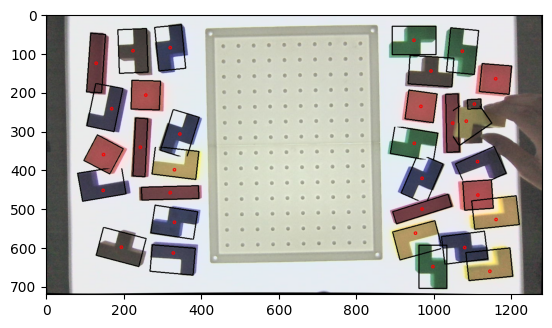

False

=== 优化后方块数据 ===

方块分配优化结果

【每种方块类型的优化效果】
类型    方块数     选中数     原始距离        优化后距离       节省距离        节省百分比       处理时间(ms)    
0     4       4       872.4385  804.8792  67.5593       7.7%    0.07
1     4       3       900.3423  552.9744  347.3680      38.6%    0.04
2     5       5       1066.9990  844.9811  222.0179      20.8%    0.05
3     4       3       979.1599  424.7562  554.4037      56.6%    0.04
4     5       4       773.2270  670.5793  102.6477      13.3%    0.04
5     5       5       1045.7544  1022.3560  23.3985       2.2%    0.05
6     5       5       1165.3295  869.1487  296.1808      25.4%    0.05

【总体优化效果】
原始总距离: 6803.2507
优化后总距离: 5189.6748
总节省距离: 1613.5759
节省百分比: 23.7%
总处理时间: 0.33 ms

【处理时间分析】
平均每类型处理时间: 0.05 ms
最长类型处理时间: 0.07 ms
最短类型处理时间: 0.04 ms

【被选中的方块】
类型 0: 选中方块索引 [0, 1, 2, 3]
类型 1: 选中方块索引 [1, 2, 3]
类型 2: 选中方块索引 [0, 1, 2, 3, 4]
类型 3: 选中方块索引 [0, 2, 3]
类型 4: 选中方块索引 [0, 2, 3, 4]
类型 5: 选中方块索引 [0, 1, 2, 3, 4]
类型 6: 选中方块索引 [0, 1, 2, 3, 4]


(6803.25065864811, 5189.674769745378)

In [41]:
coeffs_X=[-5.27024114e+02,5.02110846e-01,2.35451336e-06,2.53394337e-03,-3.58037700e-06,1.97472402e-06]#9点标定法的矩阵
coeffs_Y=[-3.01020305e+02,-6.61028609e-03,7.65574990e-06,5.03337329e-01,-6.44560884e-06,-1.85858487e-06]#9点标定法的矩阵
def get_length(point1,point2):
    return math.sqrt((point1[0]-point2[0])**2+(point1[1]-point2[1])**2)
def coreect_LL_location(box,mask,rect):#获取L方块长边偏下的位置，L方块系中间吸不到（不用细看）
    px=0
    py=0
    if(rect[1][0]>rect[1][1]):
        long_side=rect[1][0]
    else:
        long_side=rect[1][1]
    px=rect[0][0]
    py=rect[0][1]
    l1=get_length(box[0],box[1])
    l2=get_length(box[0],box[2])
    l3=get_length(box[0],box[3])
    if(l1/long_side>=0.9 and l1/long_side<=1.1):
        long1=[box[0],box[1]]
        long2=[box[2],box[3]]
    elif(l2/long_side>=0.9 and l2/long_side<=1.1):
        long1=[box[0],box[2]]
        long2=[box[1],box[3]]   
    elif(l3/long_side>=0.9 and l3/long_side<=1.1):
        long1=[box[0],box[3]]
        long2=[box[1],box[2]]   
    point1=[int((px+(long1[0][0]+long1[1][0])/2.0)/2.0),int((py+(long1[0][1]+long1[1][1])/2.0)/2.0)]
    point2=[int((px+(long2[0][0]+long2[1][0])/2.0)/2.0),int((py+(long2[0][1]+long2[1][1])/2.0)/2.0)]
    # print("mask1:",mask[point1[0]][point1[1]],point1)
    # print("mask2:",mask[point2[0]][point2[1]],point2)
    # mask[point1[0]][point1[1]]=255
    # mask[point2[0]][point2[1]]=255
    if(mask[point1[1]][point1[0]]>=1):#是是方块内
        return point1[0],point1[1]
    else:
        return point2[0],point2[1]

def get_angle(t1,t2):#判断方块是顺时针转角度小还是逆时针转角度小
    if(abs(t1)<=abs(t2)):
        return t1
    else:
        return -t2
def make_list(l,category,cam_3d,t):#将检测到的方块加入到方块表中
    x,y,z=cam_3d
    if(category=="LR"):
        l[0].append([x,y,z,t])
    elif(category=="LL"):
        l[1].append([x,y,z,t])
    elif(category=="ZL"):
        l[2].append([x,y,z,t])
    elif(category=="ZR"):
        l[3].append([x,y,z,t])
    elif(category=="O"):
        l[4].append([x,y,z,t])
    elif(category=="T"):
        l[5].append([x,y,z,t])
    elif(category=="line"):
        l[6].append([x,y,z,t])
    return l
#下面这5个函数都不用管
def calculate_bottom_left(cx, cy, w, h, theta):
    # 转换为数学标准角度（逆时针为正）
    theta_rad = np.deg2rad(-theta)
    if w < h:
        theta_rad += np.pi / 2  # 调整到短边为基准
    
    # 左下角相对于中心的偏移量（旋转前）
    dx = -w / 2
    dy = h / 2
    
    # 应用旋转矩阵
    x_rotated = dx * np.cos(theta_rad) - dy * np.sin(theta_rad)
    y_rotated = dx * np.sin(theta_rad) + dy * np.cos(theta_rad)
    
    # 转换为绝对坐标
    x = cx + x_rotated
    y = cy + y_rotated
    
    return (x, y)
def get_right_top(box,rect):
    for i in box:
        if(i[0]>rect[0][0] and i[1]<rect[0][1]):
            return i
def get_left_top(box,rect):
    for i in box:
        if(i[0]<rect[0][0] and i[1]<rect[0][1]):
            return i
def get_left_bottom(box,rect):
    for i in box:
        if(i[0]<rect[0][0] and i[1]>rect[0][1]):
            return i
def calculate_center(right_top_x, right_top_y, width, height, rotation_angle_deg):
    # 将角度转换为弧度
    theta = math.radians(rotation_angle_deg)
    
    # 计算旋转后的中心坐标
    center_x = right_top_x - (width / 2) * math.cos(theta) - (height / 2) * math.sin(theta)
    center_y = right_top_y - (width / 2) * math.sin(theta) + (height / 2) * math.cos(theta)
    
    return (center_x, center_y)
def create_polynomial_features(u, v, degree=2):
    """创建多项式特征矩阵"""
    features = []
    for i in range(degree+1):
        for j in range(degree+1):
            if i + j <= degree:
                features.append((u**i) * (v**j))
    return np.array(features)
def predict_position(coeffs, u, v, degree=2):
    """使用标定结果预测坐标"""
    features = create_polynomial_features(u, v, degree)
    X = np.dot(coeffs[0], features)
    Y = np.dot(coeffs[1], features)
    return X, Y
def put_fenlei(list):
    out_list=[[],[],[],[],[],[],[]]
    for i in list:
        tool_position=get_put_pose(i[0],i[1],board_list)
        j=[tool_position[0],tool_position[1]]
        if(i[3]=='LR'):
            out_list[0].append(j)
        elif(i[3]=='LL'):
            out_list[1].append(j)
        elif(i[3]=='ZL'):
            out_list[2].append(j)
        elif(i[3]=='ZR'):
            out_list[3].append(j)
        elif(i[3]=='O'):
            out_list[4].append(j)
        elif(i[3]=='T'):
            out_list[5].append(j)
        elif(i[3]=='line'):
            out_list[6].append(j)
    return out_list
def cube_pocess(list):
    out_list=[[],[],[],[],[],[],[]]
    cnt=0
    for i in list:
        for j in i:
            out_list[cnt].append([j[0],j[1],j[2],j[3]])
        cnt=cnt+1
    return out_list
def get_all_cube(category,cube):#LR LL ZL ZR O T Line
    if(category=="LR"):
        cube[0]=cube[0]+1
    elif(category=="LL"):
        cube[1]=cube[1]+1
    elif(category=="ZL"):
        cube[2]=cube[2]+1
    elif(category=="ZR"):
        cube[3]=cube[3]+1
    elif(category=="O"):
        cube[4]=cube[4]+1
    elif(category=="T"):
        cube[5]=cube[5]+1
    elif(category=="line"):
        cube[6]=cube[6]+1
    return cube
def fill_holes(mask):#对检测到的mask进行填充
    """
    使用 floodFill 填充二值图像中的空洞
    
    参数:
        mask (numpy.ndarray): 二值化掩码图像
    
    返回:
        numpy.ndarray: 填充空洞后的图像
    """
    # 1. 创建稍大的临时图像用于 floodFill
    h, w = mask.shape
    temp = np.zeros((h+2, w+2), dtype=np.uint8)
    
    # 2. 将原始图像复制到临时图像中心
    temp[1:-1, 1:-1] = mask
    
    # 3. 创建一个掩码用于 floodFill (需要比原图大2个像素)
    mask_flood = np.zeros((h+4, w+4), dtype=np.uint8)
    
    # 4. 从边界点开始填充背景
    # 注意：我们需要填充的是背景，然后将背景反转
    cv2.floodFill(temp, mask_flood, (0, 0), 255)
    
    # 5. 反转填充结果：现在背景为255，前景为0
    filled = cv2.bitwise_not(temp)
    
    # 6. 裁剪回原始尺寸
    return filled[1:-1, 1:-1]


def calculate_center(top_right_x, top_right_y, width, height, rotation_angle_degrees):#这个不用管
    """
    根据旋转后的矩形右上角坐标计算中心坐标
    
    参数:
        top_right_x (float): 旋转后右上角点的x坐标
        top_right_y (float): 旋转后右上角点的y坐标
        width (float): 矩形的宽度
        height (float): 矩形的高度
        rotation_angle_degrees (float): 旋转角度（度数，小于10度）
    
    返回:
        tuple: 中心坐标 (center_x, center_y)
    """
    # 将角度转换为弧度
    theta = math.radians(rotation_angle_degrees)
    
    # 计算中心坐标
    center_x = top_right_x - ( (width / 2) * math.cos(theta) - (height / 2) * math.sin(theta) )
    center_y = top_right_y - ( (width / 2) * math.sin(theta) + (height / 2) * math.cos(theta) )
    
    return center_x, center_y
length=18
all_depth=0
print("是否进行进阶任务")
jinjie=input()
if(jinjie=="y"):
    jinjie_flag=True
else:
    jinjie_flag=False
pick_list=[[1, 2, 90, 'LL'], [4, 1.5, 0, 'T'], [7.5, 1, 0, 'line'], [9.5, 2, -90, 'ZR'], [2, 3, 90, 'LL'],#基础任务的放置表
           [4, 3, 180, 'LR'], [7, 2, 0, 'LL'], [1.5, 5, 90, 'T'], [3.5, 5, 90, 'ZL'], [5, 4.5, 0, 'ZR'], 
           [6.5, 3.5, 0, 'O'], [9, 5, -90, 'LR'], [10, 4.5, 90, 'line'], [7.5, 5.5, 0, 'O'], [1.5, 7, -90, 'ZR'], 
           [3.5, 7, 90, 'ZL'], [5, 7.5, 90, 'line'], [6.5, 7, 90, 'T'], [9, 7, 0, 'LR'], [3, 9, -90, 'LR'], [7, 8.5, 180, 'T'], 
           [9.5, 8.5, 0, 'O'], [1, 10, 90, 'LL'], [4.5, 10, 90, 'T'], [6.5, 11, 90, 'ZL'], [8.5, 10, 0, 'line'], [2.5, 11, 90, 'ZL'], 
           [8, 12, 90, 'LL'], [9.5, 12, -90, 'ZR'], [1.5, 12.5, 0, 'O'], [3.5, 13, -90, 'ZR'], [5, 12.5, 90, 'line'], [6.5, 13, 90, 'ZL'], [9, 14, 180, 'LR']]
shooting_angle=[-280.575,25.665,382.61,-180,0,90]#拍摄姿态
cube_count=[0,0,0,0,0,0,0]#记录每个方块的放置个数
arm.set_tool_pose(shooting_angle)#运动到拍摄姿态
img_bgr1, depth_img, scene_pcd = camera_ros.update_camera_data() #获取图像

h, w = img_bgr1.shape[:2]
new_camera_mtx, roi = cv2.getOptimalNewCameraMatrix(camera_matrix, dist_coeff, (w, h), 1, (w, h))

img_bgr = cv2.undistort(img_bgr1, camera_matrix, dist_coeff, None, new_camera_mtx)#去畸变
cv2.imwrite("原始图像.jpg",img_bgr)
img_bgr2=np.copy(img_bgr)#复制一个数组，我们会在检测到的图片中画黑框开辅助判断，但黑框会影响颜色分割，所以复制一个数组，img_bgr用来检测画黑框，img_bgr2用来颜色分割
result = model(img_bgr,iou=0.5,conf=0.45)#yolo检测
board_list=[]#记录板子的位置和角度
cube_list=[]#检测到方块储存在这个列表中
for i in range(7):
    cube_list.append([])
board_length=304
board_width=223
print("输出检测信息")
c=math.cos(6.2192297/180.0*math.pi)


#这个目前没用不用看
for det in result[0].boxes.data.tolist():
    x1, y1, x2, y2, score, cid = det#取出识别结果
    category = model.names[int(cid)]#类别
    if(category=="O"):
        px=(int)((x1+x2)/2)        
        py=(int)((y1+y2)/2)
        depth_value=depth_img[int(py)][int(px)]
        all_depth=depth_value
        break
print("深度为:",all_depth)



top_panel_mask = np.bitwise_and(depth_img < all_depth+3, depth_img > all_depth-5)#这个目前没用不用看

board_list=[0,0,0]
#进行检测
for det in result[0].boxes.data.tolist():
    x1, y1, x2, y2, score, cid = det#取出识别结果
    category = model.names[int(cid)]#类别
    if(category=="board"):
        continue
    cube_count=get_all_cube(category,cube_count)#读取每种方块的个数
    px=(x1+x2)/2        
    py=(y1+y2)/2
    cropped_img = img_bgr[int(y1)+3:int(y2)-3, int(x1)+3:int(x2)-3]#根据yolo的框取出图像
    cropped_img2 =img_bgr2[int(y1)+3:int(y2)-3, int(x1)+3:int(x2)-3]
    cropped_img_gray = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2GRAY)#灰度化
    mask,hsv=get_mask(cropped_img,category)#颜色分割，mask是分割的图片二值化图
    cropped_depth_img = depth_img[int(y1)+3:int(y2)-3, int(x1)+3:int(x2)-3]#根据yolo的框取出图像
    contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL , cv2.CHAIN_APPROX_NONE)#获取边沿
    if(len(contours)<1):#过滤无效边缘
        continue

    #寻找边缘列表中长度最大的边缘，确保找到正确的边缘（cnt）
    index=0
    index_max=0
    len_max=0
    for cnt in contours:
        if(len(cnt)>len_max):
            len_max=len(cnt)
            index_max=index
        index=index+1
    cnt=contours[index_max]

    #根据最长的轮廓cnt来得到包含方块上表面的最小矩形框，进而得到中心点
    rect = cv2.minAreaRect(cnt)
    box = cv2.boxPoints(rect)
    box = np.int0(box)
    cv2.drawContours(cropped_img2, [box], 0, (0, 0, 0), 2)
    cv2.drawContours(mask,cnt, -1,255, -1)
    px=(int(rect[0][0])+int(x1)+3)
    py=(int(rect[0][1])+int(y1)+3)
    if(category=="LL" or category=="LR"):#L型方块要特殊处理，吸中间吸不起来
        px,py=coreect_LL_location(box,mask,rect)
        px=(px+int(x1)+3)
        py=(py+int(y1)+3)

    #给中心点画圈
    cv2.circle(img_bgr2,(px,py),3, (0, 0, 255), 2)

    #获取角度，不用看
    theta0=get_precise_angle(rect,box,category,mask)#获取角度，不用看

    #对角度进行进一步处理，把原始角度转换好
    theta_1=theta0
    theta_2=180-theta0
    if(category=="LL" or category=="LR" or category=="T"):
        theta_1=theta0
        theta_2=360-theta_1
    elif(category=="O" or category=="board"):
        theta_1=theta0%90
        theta_2=90-theta_1
    theta_1,theta_2=normalize_angle(theta_1,theta_2)
    theta=get_angle(theta_1,theta_2)


    if(category=="ZR"):
        print("ZR:",px,",",py)
        # h, w = hsv.shape[:2]
        # print(hsv[(int)(h/2)][(int)(w/2)])
        # plt.imshow(mask[:, :])
        # plt.show()
    # if(category=="LL"):
    #     # pred_X, pred_Y = predict_position((coeffs_X, coeffs_Y), px,py)
    #     # print("ZR:",px,",",py,"实际：",pred_X,pred_Y)
    #     # plt.imshow(hsv[:, :,-1])
    #     # plt.show()
    #     plt.imshow(mask[:, :])
    #     # h, w = hsv.shape[:2]
    #     print("LL:",px,py,theta)
    #     plt.show()


    depth_value=depth_img[int(py)][int(px)]#不需要了

    cam_point3d = camera.depth_pixel2cam_point3d(px, py, depth_value=depth_value)#这个也不需要，无意义，现在利用标定矩阵获取坐标，准确度更高

    #依据像素坐标预测显示3维坐标
    pred_X, pred_Y = predict_position((coeffs_X, coeffs_Y), px,py)
    predicted_z = predictor.predict(np.array([px,py]))
    cam_point3d[0]=pred_X
    cam_point3d[1]=pred_Y
    cam_point3d[2]=predicted_z

    #计算板子的坐标和角度
    if(category=='board'):
        position=get_right_top(box,rect)
        position2=get_left_bottom(box,rect)
        pred_X1, pred_Y1 = predict_position((coeffs_X, coeffs_Y),position[0]+int(x1)+3,position[1]+int(y1)+3)
        pred_X2, pred_Y2 = predict_position((coeffs_X, coeffs_Y),position2[0]+int(x1)+3,position2[1]+int(y1)+3)
        board_list.append((pred_X1+pred_X2)/2.0)
        board_list.append((pred_Y1+pred_Y2)/2.0)
        board_list.append(theta)#因为摄像头视角不是水平的，所以要修改

    #根据方块种类和坐标、角度制作方块列表
    cube_list=make_list(cube_list,category,cam_point3d,theta)

#显示图像
plt.imshow(img_bgr2[:, :, ::-1])
plt.show()
cv2.imwrite("识别结果.jpg",img_bgr2)
#如果是进阶任务，那就要生成新的摆放表
if(jinjie_flag):
    pick_list,fill_line=get_put_table(cube_count)
    print("极限填满行",fill_line)
    print(pick_list)

print(jinjie_flag)
# print("托盘数据",board_list)
pick_list2=put_fenlei(pick_list)#将摆放表按照种类顺序分类，用于后续计算
# print(pick_list2)
block=cube_pocess(cube_list)
# print(block)
# print(cube_list)


# 运行优化
results = optimize_block_assignment(block, pick_list2)
block2, selected, orig_dists, opt_dists, dist_saving, time_used, total_time, orig_total, opt_total = results

print("\n=== 优化后方块数据 ===")
# 打印结果
print_optimization_results(block2, selected, orig_dists, opt_dists, dist_saving, 
                           time_used, total_time, orig_total, opt_total)
# print(block2)
# print(block)

# print(board_list)

回到拍摄角度，跑完一遍调试用

In [302]:
sucker_off()
shooting_angle=[-280.575,25.665,382.61,-180,0,90]#拍摄姿态
arm.set_tool_pose(shooting_angle)

True

In [196]:
sucker_off()

测试放置位置是否准确

In [28]:
put_pose=get_put_pose(10,1,board_list)
put_pose[2]=149
put_pose[5]=shooting_angle[5]
arm.set_tool_pose(put_pose)#到托盘那里
print(put_pose)

[-227.454, 108.095, 149, -180, 0, 90]


In [30]:
speed=100

函数

In [37]:
x_offset= - 40 -40 -3-5 +204 -253 -10+9+1-10-1.5 +3#没用
y_offset=    -8.4 - 15+29.997-18-2+4-5.5 +2 +3+1#没用
z_offset= 100 -66 #没用


board_x_offset=-152.992-3
board_y_offset=50.996+3
cube_index=[0,0,0,0,0,0,0]
seek_angle=71#没用
def get_cube_location(cube,index_flag):#取出这个方块的位置、角度信息
    global cube_list
    global board_list
    global block2
    # cube_list=block2
    index=0
    if(cube[3]=="LR"):
        index=0
    elif(cube[3]=="LL"):
        index=1
    elif(cube[3]=="ZL"):
        index=2
    elif(cube[3]=="ZR"):
        index=3
    elif(cube[3]=="O"):
        index=4
    elif(cube[3]=="T"):
        index=5
    elif(cube[3]=="line"):
        index=6
    x=block2[index][cube_index[index]][0]
    y=block2[index][cube_index[index]][1]
    z=block2[index][cube_index[index]][2]
    t=block2[index][cube_index[index]][3]
    if(index_flag):
        cube_index[index]=cube_index[index]+1
    return x,y,z,t
def down_pick(x,y,z,t,pick_cube,board_list,index_cube):#根据位置过去捡方块
    global shooting_angle
    global pick_list
    global all_depth
    
    #计算需要旋转的角度，不用细看
    if(pick_cube[3]=="line"):
        t=(t+90)%180
    xuanzhuan_angle=pick_cube[2]-t-0.885619
    if(pick_cube[3]=="LL" or pick_cube[3]=="LR"):
        if(xuanzhuan_angle>=180):
            xuanzhuan_angle=-(360-xuanzhuan_angle)
        elif(xuanzhuan_angle<=-180):
            xuanzhuan_angle=360+xuanzhuan_angle
    elif(pick_cube[3]=="line" or pick_cube[3]=="ZR"):
        if(abs(xuanzhuan_angle)>90):
            if(xuanzhuan_angle<=0):
                xuanzhuan_angle=180+xuanzhuan_angle
            elif(xuanzhuan_angle>0):
                xuanzhuan_angle=180-xuanzhuan_angle
    elif(pick_cube[3]=="ZL"):
        if(abs(xuanzhuan_angle)>90):
            if(xuanzhuan_angle>=0):
                xuanzhuan_angle=-180+xuanzhuan_angle
    print("需要旋转的角度",xuanzhuan_angle)

    #因为是270度舵机，所以正反只有135度，为了应对170度的情况需要先预留空间
    if(xuanzhuan_angle>0):
        set_servo_angle(0)
    else:
        set_servo_angle(270)

    #先运动到方块上方再下去吸取
    shooting_angle=[-280.575,25.665,382.61,-180,0,90]#拍摄姿态
    set_angle=shooting_angle
    base_x=x
    base_y=y
    set_angle[0]=base_x
    set_angle[1]=base_y
    set_angle[2]=z+3
    set_angle[5]=shooting_angle[5]

    #如果不是第一个方块就先到上方，第一个方块可以计时开始前先过去，节约点时间
    if(index_cube!=0):
        arm.arm.MoveL(set_angle,tool=0,user=0, vel=speed)


    #吸方块
    set_angle[0]=base_x
    set_angle[1]=base_y
    set_angle[2]=z-4.5-1.5
    arm.arm.MoveL(set_angle,tool=0,user=0, vel=speed)
    sucker_in()
    shooting_angle=[-240.575,-25.665,522.61,180,0,90]

    #吸到方块后起来一点
    set_angle[2]=set_angle[2]+30
    arm.arm.MoveL(set_angle,tool=0,user=0, vel=speed)

    #开始设置舵机角度
    if(xuanzhuan_angle>0):
        set_servo_angle(xuanzhuan_angle)
    else:
        set_servo_angle(270+xuanzhuan_angle)
    return -xuanzhuan_angle,set_angle
d=1

In [40]:
sucker_off()

先运动到第一个方块的上方

In [38]:
i=0
for pick_cube in pick_list:
    x,y,z,t=get_cube_location(pick_cube,False)

    #同样先计算旋转角度
    if(pick_cube[3]=="line"):
        t=(t+90)%180
    xuanzhuan_angle=pick_cube[2]+board_list[2]-t
    if(pick_cube[3]=="LL" or pick_cube[3]=="LR"):
        if(xuanzhuan_angle>=180):
            xuanzhuan_angle=-(360-xuanzhuan_angle)
        elif(xuanzhuan_angle<=-180):
            xuanzhuan_angle=360+xuanzhuan_angle
    elif(pick_cube[3]=="line" or pick_cube[3]=="ZR"):
        if(abs(xuanzhuan_angle)>90):
            if(xuanzhuan_angle<=0):
                xuanzhuan_angle=180+xuanzhuan_angle
            elif(xuanzhuan_angle>0):
                xuanzhuan_angle=180-xuanzhuan_angle
    elif(pick_cube[3]=="ZL"):
        if(abs(xuanzhuan_angle)>90):
            if(xuanzhuan_angle>=0):
                xuanzhuan_angle=-180+xuanzhuan_angle
    print("需要旋转的角度",xuanzhuan_angle)
    if(xuanzhuan_angle>0):
        set_servo_angle(0)
    else:
        set_servo_angle(270)

    #运动到第一个方块上方，所以高度为z+3
    shooting_angle=[-280.575,25.665,382.61,180,0,90]
    set_angle=shooting_angle
    base_x=x
    base_y=y
    base_z=shooting_angle[2] - z + 100 -66 
    set_angle[0]=base_x
    set_angle[1]=base_y
    set_angle[2]=z+3
    set_angle[5]=shooting_angle[5]
    print(set_angle)
    arm.arm.MoveL(set_angle,tool=0,user=0, vel=speed)
    break


需要旋转的角度 -93.2892427444458
Sent: 270E
[-266.6207337100994, -213.9488767652407, 153.8178543832444, 180, 0, 90]


捡所有方块

In [39]:
i=0
for pick_cube in pick_list:

    #先获取方块坐标（x,y,z）和角度t
    x,y,z,t=get_cube_location(pick_cube,True)

     #捡方块
    angle,set_angle=down_pick(x,y,z,t,pick_cube,board_list,i)

    #获取这个方块摆放位置的姿态
    put_pose=get_put_pose(pick_cube[0]-0.03,pick_cube[1]+0.03,board_list)
    if(pick_cube[3]=='O'):
        put_pose=get_put_pose(pick_cube[0]-0.035,pick_cube[1]+0.06,board_list)
    print(pick_cube)
    print("旋转",angle)

    #运动到放置位置上方较高处，气泵喷气
    put_pose[2]=164#高度稍微高一点，不然会撞到方块
    put_pose[5]=shooting_angle[5]
    print(put_pose)
    arm.arm.MoveL(put_pose,tool=0,user=0, vel=speed)
    delayed_suck_out(0.2)
    # while(1):
    #     time.sleep()
    put_pose[2]=161.5
    put_pose[5]=shooting_angle[5]
    arm.arm.MoveL(put_pose,tool=0,user=0, vel=speed)
    # sucker_out()

    # time.sleep(0.1)
    #再上来，准备捡下一个方块
    put_pose[2]=put_pose[2]+12
    arm.arm.MoveL(put_pose,tool=0,user=0, vel=speed)
    i=i+1
    if(i==34):#捡完34个方块结束
        break
sucker_off()


需要旋转的角度 -94.17486174444582
Sent: 270E
Sent: 175.82513825555418E
[1, 2, 90, 'LL']
旋转 94.17486174444582
[-245.69762, -71.76362, 164, -180, 0, 90]


Exception in thread Thread-56:
Traceback (most recent call last):
  File "/usr/lib/python3.8/threading.py", line 932, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.8/threading.py", line 1254, in run
    self.function(*self.args, **self.kwargs)
  File "/tmp/ipykernel_2215/4075256728.py", line 3, in suck_out
  File "/tmp/ipykernel_2215/1145727216.py", line 35, in sucker_out
  File "electric_sucker.py", line 29, in akai_fr.electric_sucker.AkaiElectricSucker.set_solenoid_valve
  File "fr.py", line 407, in akai_fr.fr.AkaiFr.set_tool_do
  File "/usr/local/lib/python3.8/dist-packages/akai_fr/fr_xmlrpc.py", line 427, in wrapper
    result = func(self, *args, **kwargs)
  File "/usr/local/lib/python3.8/dist-packages/akai_fr/fr_xmlrpc.py", line 176, in wrapper
    result = func(self, *args, **kwargs)
  File "/usr/local/lib/python3.8/dist-packages/akai_fr/fr_xmlrpc.py", line 1311, in SetToolDO
    error = self.robot.SetToolDO(id, status, smooth, block)
  File "/usr/lib/python3.8/xmlr

需要旋转的角度 -89.62657053808594
Sent: 270E


KeyboardInterrupt: 

In [ ]:
put_pose=[-304.7,-6.995,337.042,-168.405,-2.745,90.713]
arm.arm.MoveL(put_pose,tool=0,user=0, vel=100)

In [ ]:
put_pose=[-527.436,243.369,181.129,-166.136,-3.626,74.173]
arm.arm.MoveL(put_pose,tool=0,user=0, vel=100)

In [294]:
sucker_off()

In [ ]:
sucker_in()